# Comments

Goal:
- Create new "applications" dataset that includes the follower count at that point in time and the creator location (maybe reviews?)
    - Gives us information on the quality of the applications for each deal (do they have many followers and are they close?)


General comments
- Analyse the location data we have for applications for deals
    - E.g., for physical deals, can we get an estimate of the average distance of the creator to the deal? Does it matter? How can I tie this back to the model predicting apps? 
- Remove influencer_id = 20694, it is Hugo

To-do:
- Merge the deal data with the application data to one huge dataset. 

# Init

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

import numpy as np
import pandas as pd

from src.utils import interactive_dataframe_selector

In [2]:
# Load environment variables from .env file
load_dotenv("../private_data/.env")

host = os.getenv("HOST")
db = os.getenv("DB")
port = os.getenv("PORT")
role = os.getenv("ROLE")
pw = os.getenv("PASSWORD")
engine = create_engine(f"postgresql+psycopg2://{role}:{pw}@{host}:{port}/{db}")

# Create apps dataset
- We create an apps dataset that contains all the creator metadata, so we can include it when computing the deal-aggregate statistics 
    - E.g., per deal:
        - Mean follower count
        - Distance to deal
        - Mean age (sparse but possible)
        - Nr. of active users in the month/week before the deal went live
- Merge following datasets:
    - Applications 
    - Company locations
    - deal details 
    - Applicant (influencer) details

## Applications

Clean df_apps:
- Only valid applications:
    - Correct region
    - Meets follower requirement
    - Unique application
    - Not a Barter deal: all non-barter emails are anonymized, filter where email contains anonymized

In [3]:
query = 'SELECT * FROM public.deal_applications;'
df_apps = pd.read_sql(query, engine)
# # Filter some creators that we know are dev team
# creators_to_filter = [20694, 42852]
# df_apps = df_apps[~df_apps['creator_id'].isin(creators_to_filter)]
df_apps.rename(columns={'status': 'application_status',
               'created_at': "application_created_at"}, inplace=True)

In [ ]:
query = 'SELECT * FROM public.deal_locations;'
df_deallocs = pd.read_sql(query, engine)

a = pd.merge(df_apps, df_deallocs, left_on='deal_id',
             right_on='deal_id', how='left')
a

In [23]:
set_subtract(df_apps.deal_id, df_deallocs.deal_id)

Original length: 5972
 New length: 4134


In [26]:
a = get_orphans(df_apps, df_deallocs, 'deal_id', 'deal_id')
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
65,019689fa-d5d2-00c9-bcaa-0c488fd0554b,636,944.0,019689e2-2164-00c8-219f-7087bbc8918a,3534,None,2025-01-10 00:00:00+00:00,cancelled,NaT,None,NaN,None,2025-01-04 22:49:53.579502,2025-05-01 03:54:02.011077,2025-01-07 14:56:52.365254+00:00,94234.0,[other],019bb120-a7c3-015f-9971-eb1cb36d251e,01992995-ab02-0065-9713-73e86751676b
71,019bb96e-e8d9-00c9-90df-6d1e768d63bd,0,NaN,0199e7b9-68e4-00c8-a7b1-a0daa9a71be4,3014,None,NaT,waiting_approval,NaT,None,NaN,None,2026-01-13 22:16:52.185185,2026-01-13 22:16:52.185185,NaT,NaN,[other],None,0199e703-aa3f-0065-65d9-06a7a48de7d2
173,01968a12-c21d-00c9-8e3e-a3896edeb6e0,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,2972,None,2024-02-29 00:00:00+00:00,cancelled,NaT,None,NaN,None,2024-02-29 16:58:23.629984,2026-01-12 07:42:36.612109,NaT,25525.0,[other],019bb120-866b-015f-b1ab-a55f06e9797f,01992995-5bff-0065-bec2-80c9e80ab13a
174,01968a12-b5cd-00c9-1b9b-a76ad846b7be,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,8023,None,2024-03-29 00:00:00+00:00,cancelled,NaT,None,NaN,None,2024-03-12 21:30:01.818682,2026-01-12 07:42:36.612109,NaT,27756.0,[other],019bb120-866b-015f-b1ab-a55f06e9797f,01992995-5bff-0065-bec2-80c9e80ab13a
175,01968a12-b7ae-00c9-ce39-7ea158a2b81a,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,1552,None,2024-02-21 00:00:00+00:00,cancelled,NaT,None,NaN,None,2024-02-21 10:32:22.680961,2026-01-12 07:42:36.612109,NaT,23626.0,[other],019bb120-866b-015f-b1ab-a55f06e9797f,01992995-5bff-0065-bec2-80c9e80ab13a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269722,019b0354-ef35-00c9-3024-3ca58c5f4a46,3432,NaN,019ae42b-dbbe-00c8-cac5-e2a6178040c4,7718,None,NaT,waiting_approval,NaT,None,NaN,None,2025-12-09 13:37:36.565332,2025-12-09 13:37:36.565332,NaT,NaN,[other],None,019ae3f1-58ad-0065-f78d-d84079fa3663
269723,019b0358-d7e7-00c9-7370-3dc80688505c,1102,NaN,019ac0b8-a811-00c8-1765-13df3566b3b3,35657,None,NaT,waiting_approval,NaT,None,NaN,None,2025-12-09 13:41:52.743434,2025-12-09 13:41:52.743434,NaT,NaN,[other],None,01992996-0902-0065-1266-c7bd51370c93
269725,019689ef-9471-00c9-2972-04a4f387518b,1476,2072.0,019689e3-8231-00c8-45a1-02e2709942dc,16575,None,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:08:35.808610+00:00,creator,25389.0,,2025-04-28 20:53:30.938432,2026-01-12 07:42:27.451628,NaT,149850.0,[other],019bb120-b24d-015f-f415-40b5326ee9b7,01992996-4fdb-0065-a9c0-b0e72b133d70
269732,019b35ca-82f4-00c9-2635-8b8fcfeb7a4e,3454,NaN,019b359e-7880-00c8-ba13-e73e44044ea9,36953,None,2025-12-22 23:00:00+00:00,accepted,NaT,None,NaN,None,2025-12-19 08:47:02.900519,2026-02-17 17:31:17.671683,NaT,NaN,[other],None,019ae9f8-ea0b-0065-e43c-341e8dd7b885


In [20]:
df_deallocs.deal_id.value_counts()

deal_id
019689e5-2cd1-00c8-4b9f-b9a9bc1b08ec    34
019689e5-2579-00c8-26b4-6bd7d9690077    34
019adf06-954d-00c8-85e7-aa245fd7b9fa    13
0198044d-99e3-00c8-903c-01910cefb643    12
01978c65-2d8d-00c8-fa1b-fed7a14409c9    12
                                        ..
019689e1-f2f0-00c8-6552-a5f2106971ac     1
019689e1-f4d9-00c8-5b33-ead34074a6e7     1
019689e1-f4de-00c8-d3bc-b196a08582f5     1
019689e1-f828-00c8-a5df-8597115c240c     1
019689e4-661a-00c8-eea3-03d928e746c0     1
Name: count, Length: 2388, dtype: int64

## Influencers/ creators

In [4]:
# 1. Wrap the entire row in a JSON blob using the database's native function
# 'row_to_json' works for PostgreSQL. For MySQL use 'JSON_OBJECT'.
query = "SELECT row_to_json(t) as data_blob FROM public.influencers_table_view t;"

# 2. Read the JSON blobs (Pandas receives them as a column of dictionaries)
df_wrapper = pd.read_sql(query, engine)

# 3. Expand the dictionaries back into a proper DataFrame
df_creators = pd.json_normalize(df_wrapper['data_blob'])

# Now you have your full dataframe, and dates are just Strings.
# You can clean them safely without crashing.
df_creators['birthday'] = pd.to_datetime(
    df_creators['birthday'], errors='coerce')
df_creators['created_at'] = pd.to_datetime(
    df_creators['created_at'], errors='coerce')

df_creators.rename(columns={'status': 'status_creator',
                            "created_at": "created_at_creator",
                            "longitude": "longitude_creator",
                            "latitude": "latitude_creator"}, inplace=True)
# df_creators = df_creators.add_suffix('_creator')

In [5]:
# right_cols_to_merge = ['influencer_id', 'user_id', 'gender', 'birthday', 'creator_created_at', 'creator_status', 'socials', 'country', 'address_name', 'latitude', 'longitude']
# df_apps = pd.merge(df_apps, df_creators[right_cols_to_merge], left_on='creator_id', right_on='influencer_id', how='left')

## Partners

In [6]:
query = 'SELECT * FROM public.partners_table_view;'
df_partners = pd.read_sql(query, engine)

mask = df_partners['email_address'].str.contains('anonymized')
df_partners_invalid = df_partners[~mask]
df_partners = df_partners[mask]

# df_apps.rename(columns={'status': 'application_status', 'created_at': "application_created_at"}, inplace=True)

## Deals dataset

In [7]:
# Define your column lists
cols_deals = ['created_at', 'updated_at', 'deleted_at', 'id', 'legacy_partner_id', 'title', 'description', 'creators_requirement', 'hash_tags', 'status', 'deal_value', 'go_live_at', 'live_until', 'deal_type',
              'images', 'accepts_international', 'accepted_countries', 'social_requirement_type_id', 'product_name', 'schedule_type', 'schedule_model', 'legacy_id', 'tags', 'gender', 'featured_image', 'company_id', 'partner_id']
cols_comp = ['applicants_applications_count', 'cancelled_applications_count', 'company_locations', 'completed_applications_count', 'content_types', 'deal_created_at', 'deal_deleted_at', 'deal_id', 'deal_tags', 'deal_updated_at',
             'first_application_at', 'last_application_at', 'live_since', 'main_image', 'min_social_media_followers', 'pending_applications_count', 'planned_applications_count', 'rejected_applications_count', 'total_company_locations']

# 1. Load Deals
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

# 2. Load Deals Computed with built-in date parsing
# We add deal_id::text as deal_id_str directly in the SQL string
query_comp = f"""
    SELECT {', '.join(cols_comp)}, deal_id::text AS deal_id_str 
    FROM public.deals_computed;
"""

df_deals_comp = pd.read_sql(
    query_comp,
    engine,
    parse_dates=['first_application_at', 'last_application_at']
)

# Merge
df_deals = pd.merge(df_deals,
                    df_deals_comp,
                    left_on='id', right_on='deal_id')

del df_deals_comp

## Locations

In [8]:
cols_locations = ['created_at', 'updated_at', 'deleted_at', 'id', 'company_id', 'partner_id', 'migrated_from_location_id',
                  'name',  'address', 'postal_code', 'country', 'latitude', 'longitude', 'country_code', 'town_slug']

query_locations = f"SELECT {', '.join(cols_locations)} FROM public.company_locations;"

# query = 'SELECT * FROM public.company_locations;'
df_locations = pd.read_sql(query_locations, engine)
df_locations = df_locations[df_locations['address'] != ""]


def extract_city(row):
    address = str(row['address'])
    postcode = str(row['postal_code'])

    # Split the address by comma
    parts = address.split(',')

    # Find the segment that contains the postcode
    for part in parts:
        if postcode in part:
            # Remove the postcode from that segment and strip whitespace
            clean_city = part.replace(postcode, '').strip()
            return clean_city

    if len(parts) > 1:
        parts2 = parts[-2].split(" ")
        return parts2[-1]
        # if len(parts2) == 1:
        #     return parts2
        # else:
        #     return parts2[-1]

    else:
        return parts[0]


# Apply only to the masked rows
df_locations.loc[:, 'city'] = df_locations.apply(extract_city, axis=1)
df_locations = df_locations.add_suffix('_partner')

# Merge

df_apps, df_creators, df_deals, df_locations, df_partners (?)

Problem with the merge: df_location and df_apps do not merge on company_location_id; there are still rows for which there is a location (we know because it is in df_deals), but the company_location_id is not in df_apps so it does not merge from df_location. 

Solution: we also have another id, legacy_location_id (migrated_from_location_id_partner). However, these IDs is also incomplete. Together, the legacy IDs and the company_location_ids should cover all rows in df_apps for the physical deals. The mapping between legacy IDs and company_location_ids is contained in df_location. Therefore, we check where df_apps['company_location_id'].isna() & df_apps['legacy_location_id'].notna() and fill in the legacy_location_id with the mapping. 

In [9]:
creator_cols = ['influencer_id', 'user_id', 'name', 'email_address', 'phone_number',
                'country_code', 'gender', 'birthday', 'url', 'created_at_creator',
                'status_creator', 'socials', 'country', 'formatted_address',
                'address_name', 'latitude_creator', 'longitude_creator', 'place_id', 'state_machine']


# Create a dictionary: { 1205 : 'a1b2-c3d4', ... }
# Drop NaNs to keep the dictionary clean
df_locations['migrated_from_location_id_partner'] = df_locations['migrated_from_location_id_partner'].astype(
    'Int64')
legacy_to_modern_map = df_locations.dropna(subset=['migrated_from_location_id_partner'])\
    .set_index('migrated_from_location_id_partner')['id_partner']\
    .to_dict()

# 1. Find rows where Modern ID is missing but Legacy ID exists
mask_needs_translation = (
    df_apps['company_location_id'].isna() &
    df_apps['legacy_location_id'].notna()
)

# 2. Translate Legacy -> Modern for those specific rows
# We use .map() which is very fast
translated_ids = df_apps.loc[mask_needs_translation,
                             'legacy_location_id'].map(legacy_to_modern_map)

# 3. Fill the gaps
df_apps.loc[mask_needs_translation, 'company_location_id'] = translated_ids

# To speed up the merge, subset df_locations with rows that are actually in df_apps
ids_to_find = df_apps['company_location_id'].dropna().unique()

# Filter locations to ONLY those IDs
df_locations_subset = df_locations[
    df_locations['id_partner'].isin(ids_to_find)
]


df_apps_fin = df_apps.copy()
df_apps_fin = pd.merge(df_apps_fin, df_locations_subset, left_on='company_location_id',
                       right_on='id_partner', how='left', suffixes=('_apps', '_loc'))
df_apps_fin = pd.merge(df_apps_fin, df_deals, left_on='deal_id',
                       right_on='deal_id', how='left', suffixes=('', '_deals'))
df_apps_fin = pd.merge(df_apps_fin, df_creators[creator_cols], left_on='creator_id',
                       right_on='influencer_id', how='left', suffixes=('', '_creator'))

In [9]:
df_apps_fin

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
0,01968a12-5eb3-00c9-257e-fa635b74dff3,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,8162,None,2024-04-12 00:00:00+00:00,rejected,NaT,None,...,2024-03-14 12:44:44.122705+00:00,Active,"[{'id': 10749, 'social_media': 'Tiktok', 'foll...",Belgium,"Diest, Belgium",Diest,50.979461,5.055686,ChIJHbfyWcU4wUcR8E9NL6uZAAQ,NaN
1,01968a12-6160-00c9-70e2-d16ac7b81b69,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,7787,None,2024-03-26 00:00:00+00:00,cancelled,NaT,None,...,2024-02-27 17:02:43.442790+00:00,Active,"[{'id': 10160, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
2,01968a12-971c-00c9-0045-283966576a8f,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,7827,None,2024-05-29 00:00:00+00:00,accepted,NaT,None,...,2024-02-28 12:30:36.449667+00:00,Active,"[{'id': 10227, 'social_media': 'Tiktok', 'foll...",Belgium,"Antwerp, Belgium",Antwerp,51.219930,4.414990,ChIJfYjDv472w0cRuIqogoRErz4,NaN
3,01968a12-87b1-00c9-3f38-37d8b2ac6b33,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,358,None,2024-07-19 00:00:00+00:00,accepted,NaT,None,...,2023-10-05 21:15:17.888490+00:00,Active,"[{'id': 393, 'social_media': 'Instagram', 'fol...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
4,01968a12-8f9c-00c9-d930-9886662a3e52,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,343,None,2024-05-20 00:00:00+00:00,accepted,NaT,None,...,2023-10-04 18:00:42.491892+00:00,Active,"[{'id': 377, 'social_media': 'Instagram', 'fol...",None,None,None,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269729,019c6b5b-9898-00c9-41f6-5f00f6e5e557,0,NaN,019689e4-4bc6-00c8-6ff0-06aca342b058,42288,None,2026-02-18 00:00:00+00:00,finished,NaT,None,...,2026-01-27 08:18:43.376747+00:00,Active,"[{'id': 43692, 'social_media': 'Tiktok', 'foll...",Netherlands,"Diepenveen, Netherlands",Diepenveen,52.291527,6.148591,ChIJ8RGnLfDpx0cRZEZtD1kmqCk,NaN
269730,01968a13-eb3f-00c9-c612-691e974be348,77,102.0,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,None,2024-06-29 00:00:00+00:00,finished,NaT,None,...,2023-11-21 16:22:24.640519+00:00,Active,"[{'id': 1984, 'social_media': 'Tiktok', 'follo...",Netherlands,"Utrecht, Netherlands",Utrecht,52.091925,5.122957,ChIJNy3TOUNvxkcR6UqvGUz8yNY,NaN
269731,01968a13-eb5d-00c9-e4ea-4d663f651485,77,102.0,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,None,2024-07-06 00:00:00+00:00,finished,NaT,None,...,2023-11-21 16:22:24.640519+00:00,Active,"[{'id': 1984, 'social_media': 'Tiktok', 'follo...",Netherlands,"Utrecht, Netherlands",Utrecht,52.091925,5.122957,ChIJNy3TOUNvxkcR6UqvGUz8yNY,NaN
269732,019b35ca-82f4-00c9-2635-8b8fcfeb7a4e,3454,NaN,019b359e-7880-00c8-ba13-e73e44044ea9,36953,None,2025-12-22 23:00:00+00:00,accepted,NaT,None,...,2025-11-15 20:47:11.074719+00:00,Active,"[{'id': 41546, 'social_media': 'Tiktok', 'foll...",Netherlands,"Heemskerk, Netherlands",Heemskerk,52.514146,4.682137,ChIJE6QWKWBVz0cR52kAhnU_tpA,NaN


# Trying to solve the mystery of lost data when merging deals

To-do
- How does df_deals_comp have more locations than I can find with company locations?
- How serious is the problem; that is, how many deals do not have locations that should have them?
- Can I find whether online deals are actually physical?

Notes
- I have discovered that some deals without location do actually have a location (e.g., Try our sauna at Rotterdam Rijnhaven - FOR FREE); it shows in the backoffice. Where are they hiding in the database?
- When I check df_deals, all physical deals have locations. Should I just consider this as my ground truth? 
    - When I check which df_apps rows remain after subtracting the deals from df_deals, there are only around 50, most of them with company_location_id

In [30]:
a = get_orphans(df_apps, df_deals, 'deal_id', 'deal_id')
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
24105,019c7080-c614-00c9-41bb-6bb68c7318d4,0,NaN,019c707e-037c-00c8-61f7-9b57883ee7c2,97,None,NaT,waiting_approval,NaT,None,NaN,None,2026-02-18 11:26:53.460477,2026-02-18 11:26:53.460477,NaT,NaN,[other],None,01992995-2502-0065-6f16-4b20492e8493
47280,019689f2-5b6b-00c9-2e7c-c4acf19f1f14,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-06 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-01 16:36:09.259533,2026-01-12 07:42:37.216878,NaT,7811.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47281,019689f2-5b90-00c9-5024-24fa0fb623b7,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.264904,2026-01-12 07:42:37.216878,NaT,7812.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47282,019689f2-5bc8-00c9-ca68-a814a253cddc,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-13 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.268718,2026-01-12 07:42:37.216878,NaT,7813.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47283,019689f2-5bf4-00c9-a5a2-2b169d9ee07d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,215,None,2023-12-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 22:13:05.150193,2026-01-12 07:42:37.216878,NaT,7849.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179658,01968a19-ab3a-00c9-7334-90447722d5a9,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,571,None,2023-12-13 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-27 10:21:03.200578,2025-05-01 04:27:40.404096,2023-11-29 18:04:46.455445+00:00,6595.0,[other],019bb11e-b92b-015f-8aad-ee518d66b2f9,01992995-3265-0065-80b3-cbe49fe4be26
179659,01968a19-ab96-00c9-2f23-6e45d49d213f,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,688,None,2023-11-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-22 01:00:25.933274,2025-05-01 04:27:40.416454,2023-11-29 18:04:46.455445+00:00,6251.0,[other],019bb11e-b92b-015f-8aad-ee518d66b2f9,01992995-3265-0065-80b3-cbe49fe4be26
182175,019689f2-5d57-00c9-dd9e-26145c2453b8,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,2604,None,2023-12-07 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-07 16:17:19.040714,2025-05-01 04:29:27.608062,2023-12-13 12:35:44.841774+00:00,9246.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
182176,019689f2-5a34-00c9-f61b-3bccc153f69d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-28 00:00:00+00:00,finished,NaT,None,NaN,None,2023-12-06 08:17:40.787043,2026-01-12 07:42:37.216878,NaT,8977.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143


In [21]:
import uuid


def set_subtract(series_A, series_B, return_len=True):
    setdiff = set(series_A) - set(series_B)
    if return_len:
        return print(f"Original length: {len(set(series_A))}\n New length: {len(setdiff)}")
    return setdiff


def get_orphans(series_A, series_B, col_A, col_B):
    # # 1. Get the unique set of existing deal IDs (faster lookup)
    existing_deal_ids = series_B[col_B].unique()

    # # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
    # # The tilde (~) means "NOT"
    mask_orphans = ~series_A[col_A].isin(existing_deal_ids)

    # # 3. Create the subset
    return series_A[mask_orphans]


def ulid_to_uuid(ulid_str):
    # Crockford's Base32 Alphabet
    _crockford = "0123456789ABCDEFGHJKMNPQRSTVWXYZ"
    # Create a mapping from char to value
    _map = {c: i for i, c in enumerate(_crockford)}

    # Normalize input
    s = ulid_str.upper().replace("-", "").replace("O",
                                                  "0").replace("I", "1").replace("L", "1")

    # Decode 26 characters (Base32) -> 128-bit integer
    val = 0
    for char in s:
        val = (val << 5) | _map[char]

    # Convert 128-bit integer to UUID
    return str(uuid.UUID(int=val))

In [15]:
df_apps_fin[['deal_id', 'id_deals']]

,deal_id,id_deals
0,019689e3-9b82-00c8-52df-2e22979a06ee,019689e3-9b82-00c8-52df-2e22979a06ee
1,019689e3-9b82-00c8-52df-2e22979a06ee,019689e3-9b82-00c8-52df-2e22979a06ee
2,019689e3-9b82-00c8-52df-2e22979a06ee,019689e3-9b82-00c8-52df-2e22979a06ee
3,019689e3-9b82-00c8-52df-2e22979a06ee,019689e3-9b82-00c8-52df-2e22979a06ee
4,019689e3-9b82-00c8-52df-2e22979a06ee,019689e3-9b82-00c8-52df-2e22979a06ee
...,...,...
269729,019689e4-4bc6-00c8-6ff0-06aca342b058,019689e4-4bc6-00c8-6ff0-06aca342b058
269730,019689e4-4bc6-00c8-6ff0-06aca342b058,019689e4-4bc6-00c8-6ff0-06aca342b058
269731,019689e4-4bc6-00c8-6ff0-06aca342b058,019689e4-4bc6-00c8-6ff0-06aca342b058
269732,019b359e-7880-00c8-ba13-e73e44044ea9,019b359e-7880-00c8-ba13-e73e44044ea9


In [11]:
# This df contains the deals for which there are locations, but which are not merged from using company_locations
mask = df_apps_fin.company_id_partner.isna() & ~df_apps_fin.company_locations.isna()
df_nonmissing = df_apps_fin[mask]
df_nonmissing

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
26682,01973111-3a64-00c9-3750-4bf355376897,1351,NaN,01972b20-5c57-00c8-0341-5b175acbee3d,8857,None,2025-06-14 22:00:00+00:00,waiting_approval,NaT,None,...,2024-04-04 11:07:47.998229+00:00,Active,"[{'id': 11668, 'social_media': 'Tiktok', 'foll...",Netherlands,"Rotterdam, Netherlands",Rotterdam,51.924420,4.477733,ChIJfcRUX2C3xUcRhUtelay7KVI,NaN
48313,019bd549-6c36-00c9-66db-ed0cc0db45a9,0,NaN,019bc246-f543-00c8-1e32-b8825d49eda0,1799,None,NaT,waiting_approval,NaT,None,...,2023-11-26 17:09:36.744352+00:00,Active,"[{'id': 2275, 'social_media': 'Instagram', 'fo...",Netherlands,"Wierden, Netherlands",Wierden,52.358260,6.593873,ChIJEZF0EI_3x0cRAGUejVreAAQ,NaN
95684,019bb866-9c92-00c9-6da5-c67a046b427f,0,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,41291,None,2026-01-30 23:00:00+00:00,waiting_approval,NaT,None,...,2026-01-07 19:25:24.149560+00:00,Active,"[{'id': 42626, 'social_media': 'Instagram', 'f...",Nederland,"Eindhoven, Nederland",Eindhoven,51.423142,5.462290,ChIJn8N5VRvZxkcRmLlkgWTSmvM,NaN
96007,019bbbfc-f27f-00c9-d7cf-fe9a2e0f9dae,0,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,40965,None,2026-01-15 23:00:00+00:00,waiting_approval,NaT,None,...,2025-12-27 21:47:26.663884+00:00,Active,"[{'id': 42340, 'social_media': 'Tiktok', 'foll...",Germany,"70 Stuttgart, Germany",Stuttgart,48.775846,9.182932,ChIJ04-twTTbmUcR5M-RdxzB1Xk,NaN
96624,019bb8b9-d3a0-00c9-9aec-42aede5b947c,0,NaN,01998c83-38f0-00c8-d386-757c6dcd642a,30270,None,NaT,waiting_approval,NaT,None,...,2025-06-19 14:47:40.403006+00:00,Active,"[{'id': 31755, 'social_media': 'Instagram', 'f...",Germany,"66 Saarbrücken, Germany",Saarbrücken,49.238170,6.997547,ChIJ68AC41KxlUcRgGvbENXUIgQ,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264522,019adb0a-f224-00c9-b656-e70c1ccf2cc7,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,38188,None,2025-12-02 23:00:00+00:00,waiting_approval,NaT,None,...,2025-11-28 09:33:00.842207+00:00,Active,"[{'id': 39564, 'social_media': 'Instagram', 'f...",Germany,"44 Dortmund, Germany",Dortmund,51.513587,7.465298,ChIJEXrwv2AXuUcRUIdUMYHyJwQ,NaN
267407,019b9360-77f9-00c9-a5a7-41552d9ce9bf,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,28771,None,2026-01-06 23:00:00+00:00,waiting_approval,NaT,None,...,2025-05-13 01:00:49.675299+00:00,Active,"[{'id': 38903, 'social_media': 'Instagram', 'f...",Germany,"45 Essen, Germany",Essen,51.457557,7.022463,ChIJOfarlrfCuEcRnSytpBHhAGo,NaN
268048,019af35d-f6d5-00c9-d415-99f79cad593e,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,37658,None,2026-01-22 23:00:00+00:00,waiting_approval,NaT,None,...,2025-11-17 13:08:47.312642+00:00,Active,"[{'id': 39039, 'social_media': 'Instagram', 'f...",Deutschland,"86 Augsburg, Deutschland",Augsburg,48.370545,10.897790,ChIJKSshOsWinkcRoOeL161IHgQ,NaN
268312,019af300-e127-00c9-d1b3-0fdb4dd606c4,2664,NaN,01998bba-b7b9-00c8-df86-48cec5319323,38092,None,NaT,accepted,NaT,None,...,2025-11-26 10:40:15.095259+00:00,Active,"[{'id': 39473, 'social_media': 'Tiktok', 'foll...",Deutschland,"61203 Reichelsheim (Wetterau), Deutschland",Reichelsheim (Wetterau),50.358697,8.873952,ChIJQd2UFLvivEcRjC6-c3vdMM8,NaN


In [ ]:

# Your ID
ulid_id = "01K6D4JBZN0340EPM6D3SC74AH"
print(f"UUID: {ulid_to_uuid(ulid_id)}")

UUID: 01999a49-2ff5-00c8-075a-8668f2c39151


I can check this deal for inspiration: 01992996-c732-0065-d35a-06f77ffd5a04


In [23]:
query_deals = f"SELECT * FROM public.deal_locations_computed;"
df_dealsloc = pd.read_sql(query_deals, engine)

a = get_orphans(df_apps_fin, df_dealsloc, 'deal_id', 'deal_id')
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
65,019689fa-d5d2-00c9-bcaa-0c488fd0554b,636,944.0,019689e2-2164-00c8-219f-7087bbc8918a,3534,None,2025-01-10 00:00:00+00:00,cancelled,NaT,None,...,2023-12-18 06:33:05.598348+00:00,Active,"[{'id': 10217, 'social_media': 'Instagram', 'f...",Netherlands,"Wijk bij Duurstede, Netherlands",Wijk bij Duurstede,51.975600,5.338449,ChIJQ_HGU6pexkcRvcw0C35I4pk,NaN
71,019bb96e-e8d9-00c9-90df-6d1e768d63bd,0,NaN,0199e7b9-68e4-00c8-a7b1-a0daa9a71be4,3014,None,NaT,waiting_approval,NaT,None,...,2023-12-13 18:08:23.819215+00:00,Active,"[{'id': 21263, 'social_media': 'Tiktok', 'foll...",Netherlands,"Nederland, Netherlands",Nederland,52.754978,5.965252,ChIJL54ew-RkyEcRRTtn98pp50g,NaN
173,01968a12-c21d-00c9-8e3e-a3896edeb6e0,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,2972,None,2024-02-29 00:00:00+00:00,cancelled,NaT,None,...,2023-12-13 15:48:57.166807+00:00,Active,"[{'id': 16790, 'social_media': 'Tiktok', 'foll...",Netherlands,"Waalwijk, Netherlands",Waalwijk,51.687895,5.057482,ChIJc8b6nx6RxkcREH4ejVreAAQ,NaN
174,01968a12-b5cd-00c9-1b9b-a76ad846b7be,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,8023,None,2024-03-29 00:00:00+00:00,cancelled,NaT,None,...,2024-03-04 18:48:27.442990+00:00,Active,None,None,None,None,NaN,NaN,None,NaN
175,01968a12-b7ae-00c9-ce39-7ea158a2b81a,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,1552,None,2024-02-21 00:00:00+00:00,cancelled,NaT,None,...,2023-11-21 05:04:46.003754+00:00,Active,"[{'id': 2378, 'social_media': 'Tiktok', 'follo...",Netherlands,"IJmuiden, Netherlands",IJmuiden,52.456954,4.606014,ChIJPa9QjMvxxUcRLjlgGEEmTt0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269721,019b032e-8fe8-00c9-fc86-681315a8d96f,3432,NaN,019ae87e-777f-00c8-7787-6b395f96ae1f,7106,None,NaT,cancelled,2025-12-09 12:56:58.659352+00:00,creator,...,2024-02-15 22:56:11.747587+00:00,Active,"[{'id': 9308, 'social_media': 'Instagram', 'fo...",Belgium,"Antwerp, Belgium",Antwerp,51.219930,4.414990,ChIJfYjDv472w0cRuIqogoRErz4,NaN
269722,019b0354-ef35-00c9-3024-3ca58c5f4a46,3432,NaN,019ae42b-dbbe-00c8-cac5-e2a6178040c4,7718,None,NaT,waiting_approval,NaT,None,...,2024-02-26 11:05:20.225087+00:00,Active,"[{'id': 10452, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
269723,019b0358-d7e7-00c9-7370-3dc80688505c,1102,NaN,019ac0b8-a811-00c8-1765-13df3566b3b3,35657,None,NaT,waiting_approval,NaT,None,...,2025-10-23 12:07:11.813555+00:00,Active,"[{'id': 37709, 'social_media': 'Tiktok', 'foll...",Netherlands,"Zwolle, Netherlands",Zwolle,52.516775,6.083022,ChIJsewSnSDfx0cRjD7dkiRbC80,NaN
269725,019689ef-9471-00c9-2972-04a4f387518b,1476,2072.0,019689e3-8231-00c8-45a1-02e2709942dc,16575,None,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:08:35.808610+00:00,creator,...,2024-10-26 08:04:43.931325+00:00,Active,"[{'id': 19727, 'social_media': 'Tiktok', 'foll...",Belgium,"Ypres, Belgium",Ypres,50.857686,2.871238,ChIJ5-MgTP_O3EcRQD-E9L4185k,NaN


So company_id was introduced to distinguish between partner and their locations ('companies'), that is why there is a cutoff between the legacy id and the company id. For df_deals, when company_id is missing and deal_type is physical, we retain 497/7464 rows. Now too many of those are after the date cut-off of 04-2025, but it is relevant: e.g., Bounce Valley Delft is a different location than Rotterdam, etc. Maybe just remove these observations?

In [181]:
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

query_locations = f"SELECT {', '.join(cols_locations)} FROM public.company_locations;"
df_locations = pd.read_sql(query_locations, engine)

set_subtract(df_locations.company_id, df_deals.company_id)

Original length: 3733
 New length: 2635


In [180]:
get_orphans(df_locations, df_deals, 'partner_id', 'partner_id')

,created_at,updated_at,deleted_at,id,company_id,partner_id,migrated_from_location_id,name,address,postal_code,country,latitude,longitude,country_code,town_slug
0,2026-01-12 07:30:00.434907,2026-01-12 07:30:00.434907,NaT,019bb11c-9a72-015f-1aaf-cd186abca1d4,019bb11c-9a27-015e-3af5-de449eb1aeb4,01992995-163d-0065-552c-62553c199a9b,94.0,Samako,"Parelweg 11, 1812 RS Alkmaar, Netherlands",1812 RS,Netherlands,52.606791,4.735795,NL,Alkmaar
17,2026-01-12 07:30:02.111163,2026-01-12 07:30:02.111163,NaT,019bb11c-a0ff-015f-c33d-94b68a707d2a,019bb11c-a0d0-015e-0511-2f2501c8af21,01996ccb-9ce8-0065-84b7-d585007004ff,3282.0,Shaped1 Köln GmbH Florian Lindermann,"Handstraße 2A, 51069 Köln, Deutschland",51069,Deutschland,50.987751,7.087224,DE,Köln
38,2026-01-12 07:30:12.974704,2026-01-12 07:30:12.974704,NaT,019bb11c-cb6e-015f-6fb7-3fd9bdd301a7,019bb11c-cb4f-015e-1470-b56b355a305f,01992996-5b29-0065-6054-90d0d563ffdc,2156.0,The Kyiv Independent Store,"85 Great Portland St, London W1W 7LT, UK",W1W 7LT,UK,51.518484,-0.142214,GB,Greater London
39,2026-01-12 07:31:55.567275,2026-01-12 07:31:55.567275,NaT,019bb11e-5c2f-015f-ce72-00b2a8ab8156,019bb11e-5c09-015e-91c7-fd44822777ca,01992996-74cc-0065-88f0-4b7c68f75f93,2334.0,Elizabeth Swann Bridal,"Kasteeldreef 55, 2980 Zoersel, België",2980,België,51.250639,4.626556,BE,Antwerpen
40,2026-01-12 07:31:56.235367,2026-01-12 07:31:56.235367,NaT,019bb11e-5ecb-015f-5e89-e085053805a7,019bb11e-5e9d-015e-dfd9-038ccf8747ff,01992996-7503-0065-1027-60d597b2847e,2330.0,Head Office,"saddleworth business centre, Huddersfield Rd, ...",OL3 5DF,UK,53.564990,-2.019494,GB,Greater Manchester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3849,2026-01-29 11:03:53.197761,2026-01-29 11:03:53.197761,NaT,019c096c-866d-015f-92fc-a33be2ceb1c4,019c096c-8654-015e-b5c1-b5ce6a7c54d0,019ade7f-862f-0065-fa30-122b2c53824f,NaN,Berlin Deutschland,"Schloßstraße 129, 12163 Berlin, Deutschland",12163,Deutschland,52.464398,13.328326,DE,
3850,2026-01-29 11:23:39.109684,2026-01-29 11:23:39.109684,NaT,019c097e-9ee5-015f-03cb-8b10d013a53e,019c097e-9ec6-015e-7554-4d557c62029d,019c0976-94fb-0065-13ce-421cc11299a6,NaN,Amersfoort Nederland,"Utrechtseweg 15, 3811 NA Amersfoort, Nederland",3811 NA,Nederland,52.152457,5.381908,NL,Amersfoort
3856,2026-01-29 15:07:30.893549,2026-01-29 15:08:25.602002,NaT,019c0a4b-92cd-015f-6b0d-b190cb46ef40,019c0a21-018e-015e-3e11-9cb59e36d693,019c09eb-5ab4-0065-2ca0-81a1585adc98,NaN,Katwijk aan Zee Nederland,"Baron Sweerts de Landas Wyborghstraat, 2225 Ka...",2225,Nederland,52.203159,4.407502,NL,Katwijk
3860,2026-01-29 17:58:15.500020,2026-01-29 17:58:31.506297,NaT,019c0ae7-e4cb-015f-ea0a-86df84f4acc5,019c0ad8-77e8-015e-b3ca-164533106138,019c0aa3-7597-0065-2a5d-982d86607047,NaN,München Deutschland,"Franz-Joseph-Straße, 80801 München-Schwabing-W...",80801,Deutschland,48.157830,11.578529,DE,Oberbayern


In [124]:
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

set_subtract(df_apps.deal_id, df_deals.id)

Original length: 5971
 New length: 0


So df_deals does actually contain all the deals that are also in df_apps. Let's compare df_deals_comp


We see that these are all very old applications, which we will remove from the analysis anyways. We can discard them. 

In [168]:
query_deals_comp = f"SELECT * FROM public.deals_computed;"
df_deals_comp = pd.read_sql(query_deals_comp, engine)

set_subtract(df_apps.deal_id, df_deals_comp.deal_id)

# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals_comp['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
df_apps[mask_orphans]

Original length: 5971
 New length: 62


,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
47279,019689f2-5b6b-00c9-2e7c-c4acf19f1f14,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-06 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-01 16:36:09.259533,2026-01-12 07:42:37.216878,NaT,7811.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47280,019689f2-5b90-00c9-5024-24fa0fb623b7,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.264904,2026-01-12 07:42:37.216878,NaT,7812.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47281,019689f2-5bc8-00c9-ca68-a814a253cddc,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-13 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.268718,2026-01-12 07:42:37.216878,NaT,7813.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47282,019689f2-5bf4-00c9-a5a2-2b169d9ee07d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,215,None,2023-12-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 22:13:05.150193,2026-01-12 07:42:37.216878,NaT,7849.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47283,019689f2-59cf-00c9-c1f8-0a5af95393a6,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-06 08:17:40.783308,2026-01-12 07:42:37.216878,NaT,8976.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179657,01968a19-ab3a-00c9-7334-90447722d5a9,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,571,None,2023-12-13 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-27 10:21:03.200578,2025-05-01 04:27:40.404096,2023-11-29 18:04:46.455445+00:00,6595.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
179658,01968a19-ab96-00c9-2f23-6e45d49d213f,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,688,None,2023-11-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-22 01:00:25.933274,2025-05-01 04:27:40.416454,2023-11-29 18:04:46.455445+00:00,6251.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
182174,019689f2-5d57-00c9-dd9e-26145c2453b8,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,2604,None,2023-12-07 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-07 16:17:19.040714,2025-05-01 04:29:27.608062,2023-12-13 12:35:44.841774+00:00,9246.0,[other],None,01992995-3504-0065-7efc-2b9b0ebc8143
182175,019689f2-5a34-00c9-f61b-3bccc153f69d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-28 00:00:00+00:00,finished,NaT,None,NaN,None,2023-12-06 08:17:40.787043,2026-01-12 07:42:37.216878,NaT,8977.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143


Deals that are in df_deals but not in df_deals_comp are all archived, we can ignore them. 

In [163]:
# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals_comp['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_deals['id'].isin(existing_deal_ids)

# # 3. Create the subset
df_deals[mask_orphans]

,created_at,updated_at,deleted_at,id,legacy_partner_id,title,description,creators_requirement,hash_tags,status,...,social_requirement_type_id,product_name,schedule_type,schedule_model,legacy_id,tags,gender,featured_image,company_id,partner_id
161,2023-09-11 08:14:23.313634,2025-05-01 03:27:10.089601,2023-09-11 08:14:27.121988+00:00,019689e2-45da-00c8-54b7-3b3784f7f00b,4.0,ethd,dsgdfgh,sdghsdgh,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",67.0,None,None,None,None,01992995-1f02-0065-7322-e0ca6d678429
162,2023-09-11 01:33:24.842440,2025-05-01 03:27:08.605228,2023-11-08 09:23:33.421056+00:00,019689e2-3f57-00c8-3612-c972ebdb2144,2.0,test event,test event,test event,,archived,...,2.0,,online_indefinitely_schedule,{},64.0,None,None,None,None,01992995-169b-0065-5f8a-63ee83969775
175,2023-09-07 10:13:33.363227,2025-05-01 03:26:59.677464,2023-09-07 10:19:18.923833+00:00,019689e2-1c8a-00c8-a75a-979a73269bdf,2.0,Event Test,we test the event,the event requirement,,archived,...,2.0,,online_indefinitely_schedule,{},3.0,None,None,None,None,01992995-169b-0065-5f8a-63ee83969775
416,2023-09-19 07:57:40.431931,2025-05-01 03:27:26.778262,2023-09-19 08:31:28.413024+00:00,019689e2-86b9-00c8-4eb2-c4aa0a42f838,28.0,Wild & The Moon Kinkerstraat - Dinner,Welcome to our newest location in Amsterdam We...,"mention: New location Wild & The Moon in West,...",,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",124.0,None,None,None,None,01992995-1b32-0065-1cb5-324ee3e41b04
482,2023-09-12 08:33:32.408396,2025-05-01 03:27:12.308058,2023-09-19 08:23:51.168439+00:00,019689e2-4e78-00c8-6c8f-ed7d75cfca2e,11.0,Vunzige Deuntjes Melkweg,Free entrance for 2 with backstage access,A total of at least 2 social posts;\n- At leas...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': False, 'date_schedule_end_at'...",103.0,None,None,None,None,01992995-1769-0065-49aa-6a67b7f7af7d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,2023-11-16 16:21:30.124546,2025-05-01 03:30:51.504087,2023-11-16 16:21:51.273513+00:00,019689e5-a46b-00c8-52c1-8d2f96083f3b,58.0,Get cozied up for the winter!,ccc,ccc,,archived,...,3.0,,online_indefinitely_schedule,{},456.0,None,None,None,None,01992995-1dcf-0065-1ff3-cfebeab8fa6e
4715,2023-12-01 11:51:06.268903,2025-05-01 03:31:23.919429,2023-12-02 11:43:41.068535+00:00,019689e6-24d7-00c8-d120-82fba259f7e7,159.0,bubble tea date,We offer a Bubble Tea date for two persons: \n...,- Minimum of 2 stories or a post/real\n- feel ...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': False, 'date_schedule_end_at'...",504.0,None,None,None,None,01992995-3504-0065-7efc-2b9b0ebc8143
4718,2023-12-01 10:52:39.128842,2025-05-01 03:31:23.388269,2023-12-13 12:35:44.828913+00:00,019689e6-22a3-00c8-2afd-a63980065b3e,159.0,Bubble Tea date - Bubble Society,We offer a Bubble Tea date for two persons: \n...,- Minimum of 2 stories or a post/real\n- feel ...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",503.0,None,None,None,None,01992995-3504-0065-7efc-2b9b0ebc8143
4733,2023-12-01 15:42:18.210375,2025-05-01 03:31:29.697435,2023-12-01 15:43:37.154865+00:00,019689e6-3be4-00c8-0f48-ce98201254fb,4.0,TEST,sdafsf,dssdf,,archived,...,4.0,,online_indefinitely_schedule,{},511.0,None,None,None,None,01992995-1f02-0065-7322-e0ca6d678429


Nearly all physical deals have a location, nearly no online deals have a location

In [ ]:
len(df_deals_comp[(df_deals_comp.deal_type == 'online')
    & (~df_deals_comp.company_locations.isna())])

49

In [ ]:
df_deals_comp[(df_deals_comp.deal_type == 'physical') &
              (df_deals_comp.company_locations.isna())]

,created_at,updated_at,deleted_at,id,deal_id,title,description,legacy_partner_id,company_locations,deal_type,...,accepts_international,accepted_countries,min_social_media_followers,live_since,live_until,partner_id,rejected_applications_count,last7_days_rejected_applications_count,last14_days_rejected_applications_count,last30_days_rejected_applications_count
74,2025-05-08 09:14:56.509631,2025-05-08 09:14:56.509631,2025-05-08 09:15:08.581328+00:00,3397,0196af2d-2f47-00c8-87b4-6d83e3b6c8c2,Taco Bell - Crispy Chicken Burrito Campagne (...,Taco Bell 20 euro voucher for a great meal inc...,1473,None,physical,...,True,[NLD],5000,NaT,NaT,01992996-4a66-0065-6980-d014c57a0f9a,0,0,0,0
325,2025-09-18 15:55:59.822793,2026-02-09 03:47:40.264355,NaT,5478,01995d8a-28f9-00c8-2774-476b54c9ede4,Lunch bij Cannibale Royale (€75) 🥩🍔,Je ontvangt €75 lunchtegoed bij Cannibale Roya...,2532,None,physical,...,True,[NLD],2500,NaT,NaT,01995760-d83c-0065-faa0-a3f6cd2ca73b,0,0,0,0
1019,2026-01-22 20:59:21.810832,2026-01-22 21:13:08.496102,NaT,7747,019be781-2ddd-00c8-8273-9b4aa6b9436e,Test Media MS,<p>Test&nbsp;Media&nbsp;MSTest&nbsp;Media&nbsp...,0,None,physical,...,False,[NLD],50000,NaT,NaT,01992995-19fd-0065-d586-5198b93b87d1,0,0,0,0
1244,2025-09-18 15:56:06.344006,2026-02-09 03:47:40.558784,NaT,5479,01995d8a-3ee1-00c8-2e1e-59b297af791f,Dinner at The Lair (€125) 🍽️🔥,Je ontvangt €125 dinertegoed voor een avond si...,2532,None,physical,...,True,[NLD],2500,NaT,NaT,01995760-d83c-0065-faa0-a3f6cd2ca73b,0,0,0,0
3156,2025-09-19 13:58:45.338477,2026-02-09 03:47:48.366817,NaT,5497,01996245-2e3d-00c8-40ce-0f1c51e3f024,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 13:58:45.224948,2025-10-07 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3301,2025-09-19 14:03:29.730401,2026-02-09 03:47:48.755737,NaT,5498,01996249-8320-00c8-3f0c-7c7d8208c7b8,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 14:03:29.188158,2025-09-23 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3534,2025-09-19 14:11:04.936367,2026-02-09 03:47:49.565691,NaT,5500,01996250-772a-00c8-f799-43109b5bc83d,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 14:11:04.760224,2025-10-14 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3638,2025-11-07 10:40:35.066424,2026-01-29 13:01:00.297765,NaT,6290,019a5de7-5b1f-00c8-66fa-0fb3acfc9689,Deal test,Deal test Deal test,85,None,physical,...,True,[],50000,2025-11-07 10:40:34.832382,NaT,01992995-27fe-0065-4f9e-db8ec1e66a27,0,0,0,0
3737,2025-05-01 05:37:16.293022,2026-01-13 06:59:17.424207,NaT,983,019689e3-31de-00c8-bc32-78f173b788d0,Tegoedbon voor lunch t.w.v 100 euro,- Ontvang een lunchwaardebon t.w.v. €100 om te...,1446,None,physical,...,False,[],5000,2025-04-10 07:26:12.424848,2025-05-31 21:59:00,01992996-4c01-0065-d57f-cb513ca92c94,1,0,0,0
3784,2025-06-17 08:17:15.078312,2025-06-17 08:17:34.616847,2025-06-17 08:19:44.582573+00:00,4016,01977cf6-be7e-00c8-30b5-16da7604da41,Barter deal,Barter deal,635,None,physical,...,False,[PRT],1500,NaT,NaT,01992995-a798-0065-dc89-9c296e50120a,0,0,0,0


In [ ]:
# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals['id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
df_apps_orphaned = df_apps[mask_orphans]

In [111]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.deal_locations;'
test = pd.read_sql(query, engine)

set_subtract(df_apps.deal_id, test.deal_id)

Original length: 5971
 New length: 4133


In [113]:
set_subtract(df_apps_fin.id_deals, test.deal_id)

Original length: 5910
 New length: 4103


In [121]:
df_deals

,created_at,updated_at,deleted_at,id,legacy_partner_id,title,description,creators_requirement,hash_tags,status,...,social_requirement_type_id,product_name,schedule_type,schedule_model,legacy_id,tags,gender,featured_image,company_id,partner_id
0,2025-02-21 09:47:19.029007,2026-01-12 07:39:16.765647,NaT,019689e1-dadd-00c8-5101-e0d07384f6dd,1170.0,Heerlijke steak bij Coco's Outback in Amsterdam,Je bent welkom om nog een persoon mee te nemen...,- Vooraf spreken we een datum en tijd af. Zond...,,draft,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3463.0,None,None,None,019bb11c-cc48-015e-91e3-cb41abfcd15f,01992996-10cd-0065-a19b-1ce596e35ef1
1,2025-03-26 08:56:24.776549,2026-01-12 07:39:16.908385,NaT,019689e1-de33-00c8-297c-7a4241d57de4,745.0,Outdoor chalkboard and markers to celebrate go...,Celebrate good times with our rectangle chalkb...,-1 reel\n-1 static post\n-Share with us for ou...,,inactive,...,2.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3926.0,None,None,None,019bb11d-0225-015e-649b-bcceedc82a42,01992995-c769-0065-c083-aea03114aa15
2,2025-02-21 12:14:54.016826,2026-01-12 07:39:16.957884,NaT,019689e1-e3b3-00c8-60a3-6ff40abe4535,1081.0,Bite & Bowling,Bite & Bowling! 🎳🍽️\n\nBij Lucky’s Bowling lan...,We zoeken spontane en gezellige dames en heren...,,draft,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3466.0,None,None,None,019bb120-dbc8-015e-51fc-db0cd4579c16,01992996-0869-0065-344e-587d089c5563
3,2025-03-26 10:58:10.050719,2026-01-12 07:39:17.032326,NaT,019689e1-e796-00c8-dfeb-bc61800dd2d8,1156.0,Deze fles moet jij hebben!!,"Meta barst van de standaard productreviews, ma...",•\tHet filmpje is minimaal 15 seconden en maxi...,,live,...,3.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3929.0,None,None,None,019bb11d-065b-015e-43cd-1bb152eb2a78,01992996-1369-0065-4133-f5a8063713e0
4,2025-03-26 11:14:23.339791,2026-01-12 07:39:17.071050,NaT,019689e1-e94a-00c8-d860-fccce5580ced,1156.0,Review onze 750ml Saywhat Bottle,Onze 750ml Saywhat Bottle is de perfecte fles ...,Requirements:\n•\tHet filmpje is minimaal 15 s...,,live,...,3.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3930.0,None,None,None,019bb11d-065b-015e-43cd-1bb152eb2a78,01992996-1369-0065-4133-f5a8063713e0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7459,2026-01-14 15:27:05.788976,2026-02-12 23:03:22.265138,NaT,019bbd1e-1c3c-00c8-2820-6be3bcb01499,NaN,Gratis Coco & Sebas giftbox 🍫❤️,<p>Voor&nbsp;Valentijnsdag&nbsp;verspreidt&nbs...,<ol><li>Instagram&nbsp;Reel/story&nbsp;waarin&...,"#Cocosebas,#cocoandsebas,#chocolade,#chocolate",finished,...,4.0,https://cocosebas.nl/products/valentijns-giftbox,online_specific_date_schedule,"{'date_schedule_end_at': {'day': 12, 'year': 2...",NaN,None,unisex,uploads/deals/featured/019bbd1d-5097-ffff-26df...,019bbbb5-5e3c-015e-f821-643261d1d620,019bb767-6326-0065-5a69-08e429eb9fd9
7460,2026-02-13 16:48:04.176966,2026-02-13 16:48:04.383445,NaT,019c57e7-0650-00c8-a60e-680036aa2e06,NaN,Aute cillum ea sunt eu cupidatat consequat con...,<p></p><p>Dolor&nbsp;voluptate&nbsp;anim&nbsp;...,<p></p><p>Dolor&nbsp;voluptate&nbsp;anim&nbsp;...,"#est,#exercitation,#mollit,#nostrud,#veniam,#t...",live,...,3.0,www.moco.museum,online_indefinitely_schedule,{},NaN,[deal.new],unisex,uploads/deals/featured/019c57e6-cd54-ffff-c836...,019bb11e-1638-015e-6e4d-ac6e8c9bd984,01992995-27fe-0065-4f9e-db8ec1e66a27
7461,2026-02-04 14:49:06.767292,2026-02-04 14:49:45.677454,NaT,019c2920-e1cf-00c8-86b7-30ddb43064d3,NaN,My Continente Deal 2026 for PT,<p></p><p><span>Sonae&nbsp;Distribuição&nbsp;s...,<p></p><p><strong>Continente</strong><span>&nb...,"#2026,#continente",live,...,1.0,,online_indefinitely_schedule,{},NaN,None,unisex,uploads/deals/featured/019c2920-c31f-ffff-f6a8...,019c291f-e99

In [122]:
set_subtract(df_apps.deal_id, df_deals.id)
# # 1. Get the unique set of existing deal IDs (faster lookup)
# existing_deal_ids = df_deals['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
# mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
# df_apps_orphaned = df_apps[mask_orphans]

Original length: 5971
 New length: 0


In [117]:
df_apps_orphaned

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
47279,019689f2-5b6b-00c9-2e7c-c4acf19f1f14,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-06 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-01 16:36:09.259533,2026-01-12 07:42:37.216878,NaT,7811.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47280,019689f2-5b90-00c9-5024-24fa0fb623b7,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.264904,2026-01-12 07:42:37.216878,NaT,7812.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47281,019689f2-5bc8-00c9-ca68-a814a253cddc,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-13 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.268718,2026-01-12 07:42:37.216878,NaT,7813.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47282,019689f2-5bf4-00c9-a5a2-2b169d9ee07d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,215,None,2023-12-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 22:13:05.150193,2026-01-12 07:42:37.216878,NaT,7849.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47283,019689f2-59cf-00c9-c1f8-0a5af95393a6,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-06 08:17:40.783308,2026-01-12 07:42:37.216878,NaT,8976.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179657,01968a19-ab3a-00c9-7334-90447722d5a9,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,571,None,2023-12-13 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-27 10:21:03.200578,2025-05-01 04:27:40.404096,2023-11-29 18:04:46.455445+00:00,6595.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
179658,01968a19-ab96-00c9-2f23-6e45d49d213f,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,688,None,2023-11-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-22 01:00:25.933274,2025-05-01 04:27:40.416454,2023-11-29 18:04:46.455445+00:00,6251.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
182174,019689f2-5d57-00c9-dd9e-26145c2453b8,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,2604,None,2023-12-07 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-07 16:17:19.040714,2025-05-01 04:29:27.608062,2023-12-13 12:35:44.841774+00:00,9246.0,[other],None,01992995-3504-0065-7efc-2b9b0ebc8143
182175,019689f2-5a34-00c9-f61b-3bccc153f69d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-28 00:00:00+00:00,finished,NaT,None,NaN,None,2023-12-06 08:17:40.787043,2026-01-12 07:42:37.216878,NaT,8977.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143


In [ ]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.company_locations;'
test = pd.read_sql(query, engine)

set_subtract(df_apps.company_location_id, test.id)

set_subtract(df_apps.legacy_partner_id, test.migrated_from_location_id)

df_apps_subs = df_apps[(df_apps.legacy_location_id.isna())
                       & (df_apps.company_location_id.isna())]
set_subtract(df_apps_subs.partner_id, test.partner_id, return_len=False)

set_subtract(
    df_apps_fin[df_apps_fin.longitude_partner.isna()].place_id, test.place_id)

Original length: 1699
 New length: 1
Original length: 2002
 New length: 205
Original length: 835
 New length: 835


In [105]:
df_apps_fin.place_id

0         ChIJHbfyWcU4wUcR8E9NL6uZAAQ
1         ChIJVXealLU_xkcRja_At0z9AGY
2         ChIJfYjDv472w0cRuIqogoRErz4
3         ChIJVXealLU_xkcRja_At0z9AGY
4                                None
                     ...             
269728    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269729    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269730    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269731    ChIJNy3TOUNvxkcR6UqvGUz8yNY
269732    ChIJNy3TOUNvxkcR6UqvGUz8yNY
Name: place_id, Length: 269733, dtype: object

In [81]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.vendor_locations;'
test = pd.read_sql(query, engine)

# df_apps.rename(columns={'status': 'application_status', 'created_at': "application_created_at"}, inplace=True)

In [82]:
len(set(df_apps.partner_id) - set(test.partner_id))

31

In [80]:
len(set(df_apps.deal_id) - set(df_deals.deal_id))

62

In [79]:
len(set(df_apps.partner_id) - set(test.partner_id))

3

In [76]:
len(set(df_apps.partner_id) - set(test.company_id))

2037

In [ ]:
df_dealcomplocs['legacy_location_id'] = df_dealcomplocs['legacy_location_id'].astype(
    'Int64')
set(df_locations.migrated_from_location_id_partner) - \
    set(df_dealcomplocs.legacy_location_id)

{np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(8),
 np.int64(11),
 np.int64(15),
 np.int64(16),
 np.int64(23),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(35),
 np.int64(37),
 np.int64(38),
 np.int64(43),
 np.int64(46),
 np.int64(47),
 np.int64(49),
 np.int64(50),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(61),
 np.int64(64),
 np.int64(65),
 np.int64(67),
 np.int64(70),
 np.int64(81),
 np.int64(85),
 np.int64(89),
 np.int64(93),
 np.int64(94),
 np.int64(95),
 np.int64(97),
 np.int64(98),
 np.int64(99),
 np.int64(100),
 np.int64(101),
 np.int64(103),
 np.int64(106),
 np.int64(107),
 np.int64(110),
 np.int64(111),
 np.int64(112),
 np.int64(114),
 np.int64(124),
 np.int64(126),
 np.int64(128),
 np.int64(129),
 np.int64(130),
 np.int64(132),
 np.int64(137),
 np.int64(141),
 np.int64(144),
 np.int64(151),
 np.int64(15

In [ ]:
a = pd.merge(df_apps, df_dealcomplocs, left_on='deal_id',
             right_on='deal_id', how='left', suffixes=('_apps', '_deallocs'))

In [63]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.deal_locations;'
df_deallocs = pd.read_sql(query, engine)

df_deallocs

,deal_id,partner_location_id
0,019689e1-dadd-00c8-5101-e0d07384f6dd,1658
1,019689e1-e244-00c8-e168-433ea084d2f5,194
2,019689e1-de33-00c8-297c-7a4241d57de4,1138
3,019689e1-e3b3-00c8-60a3-6ff40abe4535,1563
4,019689e1-e3d7-00c8-2ee9-d52ab1dc434e,1138
...,...,...
2965,01999f07-050e-00c8-ae14-397443d7ccb5,3353
2966,019a2592-31f3-00c8-6756-7748fd4599f3,3267
2967,01999f17-19ad-00c8-5645-77fab27ecc19,3358
2968,0199b953-d414-00c8-ef1d-8d533c53f9ef,3391


In [43]:
set.intersection(set(df_apps.partner_id), set(df_deallocs.company_id))

set()

In [40]:
len(set(df_apps.deal_id) - set(df_deallocs.deal_id))

4218

In [ ]:
creator_cols = ['influencer_id', 'user_id', 'name', 'email_address', 'phone_number',
                'country_code', 'gender', 'birthday', 'url', 'created_at_creator',
                'status_creator', 'socials', 'country', 'formatted_address',
                'address_name', 'latitude_creator', 'longitude_creator', 'place_id', 'state_machine']

In [ ]:
a = df_apps_fin[(df_apps_fin.deal_type == 'physical') & (
    ~df_apps_fin.company_locations.isna()) & (df_apps_fin.id_partner.isna())]

Clean df_apps:
- Only valid applications:
    - Correct region
    - Meets follower requirement
    - Unique application
    - Not a Barter deal: all non-barter emails are anonymized, filter where email contains anonymized

--------

# EDA

In [15]:
a['application_status'].value_counts()

application_status
rejected            898
accepted            327
waiting_approval     25
finished              4
cancelled             3
Name: count, dtype: int64

In [13]:
a = df_apps[df_apps['deal_id'] == df_apps['deal_id'].value_counts().index[0]]
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
68576,01968a15-ff65-00c9-e03c-98b767cba7a4,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,2944,None,2024-03-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2024-03-03 15:05:28.323332,2026-01-12 07:42:38.076977,NaT,25946.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71062,01968a15-b2eb-00c9-9d7e-0b52c5ab7f96,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,674,None,2024-02-14 00:00:00+00:00,rejected,NaT,None,NaN,None,2024-01-19 17:46:57.713993,2026-01-12 07:42:38.076977,NaT,16886.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71063,01968a15-b3de-00c9-b1d8-3f6d424bd286,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,3559,None,2023-12-21 00:00:00+00:00,accepted,NaT,None,NaN,None,2023-12-19 18:51:08.862802,2026-01-12 07:42:38.076977,NaT,11973.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71064,01968a15-abfb-00c9-54ce-eab6d9261842,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,3645,None,2023-12-23 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-19 18:30:23.049072,2026-01-12 07:42:38.076977,NaT,11940.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71065,01968a15-b25c-00c9-7ae5-67637b16b05f,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,1577,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-05 10:59:43.904062,2026-01-12 07:42:38.076977,NaT,8720.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194514,01968a16-7bd8-00c9-7268-33fba5583fba,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,25165,None,2025-02-24 00:00:00+00:00,rejected,NaT,None,NaN,None,2025-02-18 11:01:19.780539,2026-01-12 07:42:38.076977,NaT,114750.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
194515,01968a16-7f5b-00c9-13b7-347dc641e46f,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,25246,None,2025-02-25 00:00:00+00:00,rejected,NaT,None,NaN,None,2025-02-19 11:21:41.757279,2026-01-12 07:42:38.076977,NaT,115364.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
200629,01980635-51d6-00c9-1425-0881e7132d14,84,NaN,019689e5-029e-00c8-9ddf-3b4d661b6e97,29706,None,NaT,waiting_approval,NaT,None,NaN,None,2025-07-13 23:53:34.422898,2025-07-13 23:53:34.422898,NaT,NaN,[other],None,01992995-2702-0065-49e4-45f3af84f0c0
201103,019809b9-4598-00c9-103c-f1846bf522f5,84,NaN,019689e5-029e-00c8-9ddf-3b4d661b6e97,30310,None,NaT,waiting_approval,NaT,None,NaN,None,2025-07-14 16:16:33.688232,2025-07-14 16:16:33.688232,NaT,NaN,[other],None,01992995-2702-0065-49e4-45f3af84f0c0


In [14]:
df_apps['deal_id'].value_counts()

deal_id
019689e5-029e-00c8-9ddf-3b4d661b6e97    1257
019689e7-7253-00c8-533e-0aac3a5c1cc7    1152
019689e3-041e-00c8-039e-1ea3e1b1da43    1127
019689e2-659b-00c8-90af-7978ca963643    1105
019689e4-253d-00c8-9317-94783504e695    1090
                                        ... 
019730a1-4d0e-00c8-6653-4fa898320737       1
0196aee0-3cb2-00c8-a72d-b81463489b22       1
0196fbf5-9877-00c8-a0a7-2a80ef770fbf       1
0196ed50-c9cb-00c8-b77d-c1a03c5b26c5       1
019ae636-7748-00c8-ab2f-3adc6bb74b91       1
Name: count, Length: 5968, dtype: int64

------
# Rest

- Location & main creators table

In [ ]:
query = """
SELECT 
    id, 
    user_id,
    name, 
    rating,
    description,
    status,
    created_at,
    CAST(updated_at AS TEXT) as updated_at,
    CAST(birthday AS TEXT) as birthday,
    gender,
    reviews_count
FROM public.influencers;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creators_og = pd.read_sql(text(query), connection)

query = """
SELECT 
    created_at,
    updated_at,
    deleted_at,
    influencer_id,
    id,
    name,
    country,
    latitude,
    longitude
FROM public.influencer_locations;
"""


with engine.connect() as connection:
    df_creatorsloc = pd.read_sql(text(query), connection)


# df_creators = df_creators[df_creators['status'] == 'Active']
df_creatorsloc.rename(columns={'name': 'city'}, inplace=True)

# Strip the timezone from both (just to be safe)
df_creators_og['created_at'] = pd.to_datetime(
    df_creators_og['created_at']).dt.tz_localize(None)
df_creatorsloc['created_at'] = pd.to_datetime(
    df_creatorsloc['created_at']).dt.tz_localize(None)

df_creatorsloc.rename(columns={'id': 'location_id'}, inplace=True)
right_cols_to_merge = ['deleted_at', 'influencer_id',
                       'location_id', 'city', 'country', 'latitude', 'longitude']
df_creators = pd.merge(
    df_creators_og,
    df_creatorsloc.loc[:, right_cols_to_merge],
    left_on='id',
    right_on='influencer_id',
    how='left'
).drop(columns='influencer_id').rename(columns={'id': 'influencer_id'})
df_creators['country'] = df_creators['country'].fillna('Unspecified')

# Standardize country names
df_creators.loc[df_creators.country == 'Nederland', 'country'] = "Netherlands"
df_creators.loc[df_creators.country == 'Belgique', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'België', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'UK', 'country'] = "United Kingdom"
df_creators.loc[df_creators.country == 'Deutschland', 'country'] = "Germany"

- Creator social media table

In [7]:
query = """
SELECT *
FROM public.influencer_social_media;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_socials = pd.read_sql(text(query), connection)

df_socials.rename(columns={'follower': 'follower_count'}, inplace=True)

In [ ]:
# Update history table, where each rows corresponds to a user that updated their follower count. Can use this for current follower count on applying
query = """
SELECT *
FROM public.social_media_update_history;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    updatehistory = pd.read_sql(text(query), connection)

363461

In [12]:
df_socials

,id,user_id,influencer_id,social_media,type,username,follower_count,created_at,updated_at,deleted_at,...,social_media_last_updated_at,external_id,token,refresh_token,token_expires_in,refresh_token_expires_in,status,validation_code,reject_reason,validated_by_user_id
0,17178,23286.0,14759.0,Tiktok,personal,daimycontehx,1267,2024-10-21 20:43:33.480775,2024-10-21 20:46:26.921411,NaT,...,2024-10-21 20:46:26.921373,_000jm-lDf4nALH8zcybqbVEjspO_dnsIdWM,act.4LIdke1egsUfISV4xlxoJT3Hb96VTUhCCvK1SNesrE...,rft.fL98UVWJh5OzRbU4GkrhGgRCTyDnga9p6hh1za3eD4...,86400.0,31535829.0,,,,NaN
1,6330,5216.0,4835.0,Tiktok,,sselaax,1224,2024-01-06 01:16:43.516333,2024-01-06 01:16:59.155028,NaT,...,NaT,None,None,None,NaN,NaN,None,None,None,NaN
2,29718,41208.0,28389.0,Tiktok,personal,fthodeexz,2446,2025-04-22 18:22:19.784935,2025-04-22 18:25:18.507892,NaT,...,2025-04-22 18:25:18.507863,_0005Sl1A4IoGgywJZsQPAZZqrBsIVUVZUqh,act.kCLVEBykSX8gK5wxLuxaUZ1JjYn3uHqOyV1w6oyPbn...,rft.lWwAedjg0sHy3lSvQVqHNQEn4Wy1DLkeL3avXbKHKt...,86400.0,31535824.0,,,,NaN
3,18077,24313.0,15636.0,Instagram,personal,nannecouvreur,762,2024-10-24 19:43:08.418089,2025-04-25 05:50:38.942422,NaT,...,2025-04-25 05:50:38.942251,,,,0.0,0.0,Approved,126012,Approved,1.0
4,14920,8639.0,8085.0,Instagram,personal,robinverkerk_,5335,2024-08-01 17:58:19.799852,2025-04-25 10:51:01.786329,NaT,...,2025-04-25 10:51:01.786295,None,None,None,NaN,NaN,Approved,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43095,27795,38726.0,26708.0,Tiktok,personal,charliejosay,7508,2025-03-08 06:00:52.503980,2026-02-13 07:44:40.255630,NaT,...,2026-02-13 07:44:40.255597,_000KWzbAhyJNNHnL5ueb-2r6puyw3Qy6ndX,act.6XKy0yKlIoO5nCtc8YJDiAcqXTBd4Nsb2UTPFsTXUY...,rft.WeWF58qMBHA1T1WJYQiZ9yRPKCjFON00bhNB4JNOko...,86400.0,1981018.0,,,,NaN
43096,32647,10464.0,9699.0,Tiktok,personal,hudasabriii,7943,2025-07-04 20:19:48.101891,2026-02-13 07:44:40.264110,NaT,...,2026-02-13 07:44:40.264069,_000cY-gORmYxUkgNoi64VsNbwuPOb-W0GYT,act.dMZdtmTFCMEkxny5z9umrXD0vp4aO2TRN31dtyAIG9...,rft.lJZfbRys0fDdp6nXHTn4Jatf0tEahYnO1AJdfssJko...,86400.0,12227740.0,,,,NaN
43097,27133,37958.0,26172.0,Tiktok,personal,almalice__,27994,2025-02-24 12:27:32.398201,2026-02-13 07:44:40.356283,NaT,...,2026-02-13 07:44:40.356256,_000R5RDZkQRDmNxb1xxgsAhMA8mHp4QSGSe,act.TjRoA4FSi9nA4uOJucq0YeUl1LoJvkk2LEpRsCsXuo...,rft.4fH64kQUwfeQxtGlHdak2BoVaMg1fbee1wCRZ5rrPm...,86400.0,967414.0,,,,NaN
43098,39510,58648.0,38134.0,Tiktok,personal,karl1en,12911,2025-11-27 00:52:16.248835,2026-02-13 07:44:40.363575,NaT,...,2026-02-13 07:44:40.363549,_000ZwKkTKHPuUPMJr5ZowE1oerOu2blkJRL,act.Q8AQdcKSjWymaLLZx6hvNy0rS27z2W4PjKkoXvJTDT...,rft.Qaf6A4deyYJyKIyqHCe6GrdzSA1DIrauEVR78djRMB...,86400.0,24772080.0,,,,NaN


In [ ]:
# Create final creator df containing all info
# We merge on user_id and not influencer_id, since it has more observations (n=2)
right_cols_to_merge = ['user_id', 'influencer_id', 'social_media', 'type', 'username',
                       'follower_count', 'display_name', 'social_media_last_updated_at', 'status']
df = pd.merge(
    df_creators,
    df_socials[right_cols_to_merge],
    left_on='user_id',
    right_on='user_id',
    how='left'
)

--------------

# Old

# Creators

## Locations

In [ ]:
query = """
SELECT 
    id, 
    user_id,
    name, 
    rating,
    description,
    status,
    created_at,
    CAST(updated_at AS TEXT) as updated_at,
    CAST(birthday AS TEXT) as birthday,
    gender,
    reviews_count
FROM public.influencers;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creators_og = pd.read_sql(text(query), connection)

query = """
SELECT 
    created_at,
    updated_at,
    influencer_id,
    name,
    country,
    latitude,
    longitude
FROM public.influencer_locations;
"""


with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creatorsloc = pd.read_sql(text(query), connection)


# df_creators = df_creators[df_creators['status'] == 'Active']
df_creatorsloc.rename(columns={'name': 'city'}, inplace=True)

# Strip the timezone from both (just to be safe)
df_creators_og['created_at'] = pd.to_datetime(
    df_creators_og['created_at']).dt.tz_localize(None)
df_creatorsloc['created_at'] = pd.to_datetime(
    df_creatorsloc['created_at']).dt.tz_localize(None)

In [ ]:
right_cols_to_merge = ['influencer_id',
                       'city', 'country', 'latitude', 'longitude']
df_creators = pd.merge(
    df_creators_og,
    df_creatorsloc.loc[:, right_cols_to_merge],
    left_on='id',
    right_on='influencer_id',
    how='left'
)
df_creators['country'] = df_creators['country'].fillna('Unspecified')

df_creators.loc[df_creators.country == 'Nederland', 'country'] = "Netherlands"
df_creators.loc[df_creators.country == 'Belgique', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'België', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'UK', 'country'] = "United Kingdom"
df_creators.loc[df_creators.country == 'Deutschland', 'country'] = "Germany"

## Social media (followers)

Mappings
- public.influencers:public.influencers_location
    - id:influencer_id
- public.influencers:public.influencer_social_media
    - user_id:user_id
- public.influencer_social_media:public.influencers_location
    - influencer_id:influencer_id
- public.deal_applications:public.influencer_social_media
    - creator_id:influencer_id

What is the difference between $id$ and $user\_id$ in the influencers table?

In [ ]:
query = """
SELECT *
FROM public.influencer_social_media;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_socials = pd.read_sql(text(query), connection)

In [ ]:
df = pd.merge(
    df_creators,
    df_socials,
    left_on='user_id',
    right_on='user_id',
    how='left'
)

df_creatorloc['influencer_id'] equals df_socials['influencer_id']. However, there are cases where creators have connected their socials but not their location. For the creators that have entered their location, influencer_id_x and influencer_id_y are equal, meaning that the merge on user_id was valid. 

In [ ]:
mask = df['influencer_id_x'].isna()
print(
    f"Occurences where influencer ids do not correspond: {sum(df.loc[mask,'influencer_id_x'] == df.loc[mask,'influencer_id_y'])}")

Occurences where influencer ids do not correspond: 0


## Deal apps 

In [8]:
query = 'SELECT * FROM public.deal_applications;'
df_apps = pd.read_sql(query, engine)
df_apps = df_apps[df_apps.creator_id != 20694]
df_apps = df_apps[df_apps.creator_id != 42852]

In [ ]:
# 1. Create a pivot table of Counts per Creator per Status
# This creates a dataframe where index is 'creator_id' and cols are 'accepted', 'finished', etc.
status_counts = pd.crosstab(df_apps['creator_id'], df_apps['status'])

# 2. Rename the columns to match your desired format (e.g. 'finished' -> 'finished_count')
status_counts.columns = [f'{col}_count' for col in status_counts.columns]

# 3. Merge it into your main dataframe
# We use right_index=True because 'creator_id' is the index of status_counts
df = df.merge(status_counts, left_on='influencer_id_y',
              right_index=True, how='left')

# 4. Fill NaNs with 0
# (If a creator isn't in df_apps, they have 0 apps, not NaN)
new_cols = status_counts.columns
df[new_cols] = df[new_cols].fillna(0).astype(int)

# Check result
# print(df[['influencer_id_y'] + list(new_cols)].head())

In [ ]:
# 1. Clean IDs first (as discussed, to enable int conversion)
clean_socials = df_socials.dropna(subset=['influencer_id']).copy()
clean_socials['influencer_id'] = clean_socials['influencer_id'].astype(int)

# 2. Sort by followers descending
# This puts the "Best" account for each person at the top
clean_socials = clean_socials.sort_values(by='follower', ascending=False)

# 3. Deduplicate keeping the Top row (The Max)
# We keep 'first' because we just sorted the biggest one to the top
unique_creators = clean_socials.drop_duplicates(
    subset=['influencer_id'], keep='first')

# 4. (Optional but Smart) Rename the column to be clear
unique_creators = unique_creators.rename(columns={'follower': 'max_followers'})

# Check the result
unique_creators

,id,user_id,influencer_id,social_media,type,username,max_followers,created_at,updated_at,deleted_at,...,social_media_last_updated_at,external_id,token,refresh_token,token_expires_in,refresh_token_expires_in,status,validation_code,reject_reason,validated_by_user_id
41535,44195,66773.0,42852,Instagram,business,championsleague,121111602,2026-02-04 14:55:13.719165,2026-02-04 14:57:36.482238,NaT,...,2026-02-04 14:57:36.482191,,,,0.0,0.0,Approved,667186,Approved,66346.0
28864,35028,30880.0,20694,Instagram,personal,Kidathegreat,4544736,2025-08-22 14:32:06.878339,2025-08-22 14:32:52.179499,2026-01-05 15:52:17.664749+00:00,...,2025-08-22 14:32:52.179468,,,,0.0,0.0,Approved,290335,Approved,1.0
41339,42062,62803.0,40722,Tiktok,personal,dutchgoalkeeper,4136035,2025-12-19 09:03:36.682403,2026-02-13 12:45:07.654720,NaT,...,2026-02-13 12:45:07.654686,_000T0vZD3vZkYlKTkZ4GeWVOdm1E-PLgLrG,act.ip2q5N9Ji54UsWGmdYheBHyKkbXZpaxdmK3YiVxpb9...,rft.FGVUz4Mrq9L81W20M0KCpKAAkdVO7zWRFEqHl8g4fz...,86400.0,26684340.0,,,,NaN
28416,5279,4409.0,4047,Instagram,personal,ivarjnr,2787531,2023-12-23 01:49:27.719728,2025-04-26 11:50:59.971479,NaT,...,2025-04-26 11:50:59.971453,None,None,None,NaN,NaN,Approved,None,None,NaN
37634,40085,59718.0,38748,Instagram,personal,sandraprikker,2745149,2025-12-06 13:37:52.694068,2025-12-08 08:53:59.928020,NaT,...,2025-12-08 08:53:59.927981,,,,0.0,0.0,Approved,497005,Approved,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12686,18269,24502.0,15806,Tiktok,personal,angelavb86,0,2024-10-24 21:20:13.464589,2024-10-24 21:22:05.527324,NaT,...,2024-10-24 21:22:05.527306,_000V8_6sC9yunperXtI5Pq1skIJ2QNIwQka,act.UhddsfNf08sCSG3CujaCZXSOQXrIYxevqczymrFfR5...,rft.9kexFjPxaDgqoNsdXJw4hjZpzdpwlnmK07BCLbhvfC...,86400.0,31535898.0,,,,NaN
12688,23744,31066.0,20837,Instagram,personal,nnassiraatje,0,2024-12-16 15:04:33.547431,2024-12-18 15:16:01.569995,NaT,...,NaT,,,,0.0,0.0,Rejected,634113,Instagram invalid/incorrect or not found,1.0
12697,15706,19304.0,11321,Tiktok,personal,ugcannebellangedijk,0,2024-08-31 17:26:17.234356,2024-08-31 17:27:30.291737,NaT,...,2024-08-31 17:27:30.291703,_000gLug2YRLnNf9aiLYqQHwC42cIL5kREqF,act.lFuxwmILHn6DCv8Ss7G6uMua4PajmOdAM7aS1ym0y2...,rft.qyM64U5lAGFyYa8a6cWS1VWMfbsOtLALJwYoin4QXA...,86400.0,31535930.0,None,None,None,NaN
12700,18292,24532.0,15829,Instagram,personal,angel.wouters,0,2024-10-24 21:25:02.239913,2024-10-25 10:04:11.794271,NaT,...,NaT,,,,0.0,0.0,Rejected,795653,No verification code sent in DM,1.0


In [ ]:
# Merge both the Max Followers AND the Platform they use
df_apps_merged = df_apps.merge(
    unique_creators[['influencer_id', 'max_followers', 'social_media']],
    left_on='creator_id',
    right_on='influencer_id',
    how='left'
)

In [ ]:
df_apps_follower_metrics = df_apps_merged.groupby(
    'deal_id')['max_followers'].agg(['count', 'mean', 'max'])
df_apps_follower_metrics

,count,mean,max
deal_id,,,
019689e1-dadd-00c8-5101-e0d07384f6dd,72,28858.166667,429170
019689e1-ddeb-00c8-5d08-8835332ab3e9,8,5042.375000,16707
019689e1-de33-00c8-297c-7a4241d57de4,9,6155.555556,16203
019689e1-e08f-00c8-c953-088b03df5152,4,3256.000000,3967
019689e1-e21b-00c8-2d1c-9c849e0682e4,5,10608.200000,16707
...,...,...,...
019c0ab1-1094-00c8-62cb-5f4de663d287,1,12395.000000,12395
019c0abc-3116-00c8-409a-3b458492e415,1,12395.000000,12395
019c0b54-a139-00c8-6c0f-67d89c75632c,2,34391.500000,59802


In [20]:
df_apps_follower_metrics[['count', 'mean']].corr()

,count,mean
count,1.000000,-0.078944
mean,-0.078944,1.000000


# Visualisations

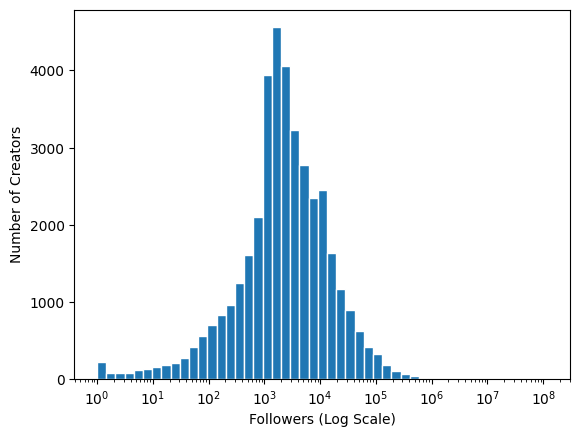

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create log-spaced bins so the bars are even on a log scale
bins = np.logspace(np.log10(df['follower'].min() + 1),
                   np.log10(df['follower'].max()), 50)

plt.hist(df['follower'], bins=bins, edgecolor='white')
plt.xscale('log')  # This is the key line
plt.xlabel('Followers (Log Scale)')
plt.ylabel('Number of Creators')
plt.show()

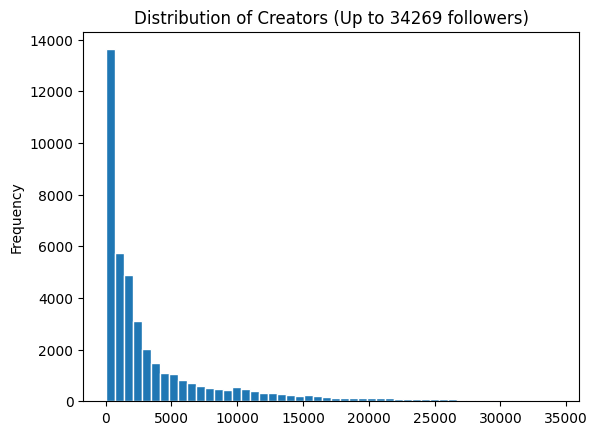

In [ ]:
# Only plot creators up to the 95th percentile
upper_limit = df['follower'].quantile(0.95)
df[df['follower'] <= upper_limit]['follower'].plot.hist(
    bins=50, edgecolor='white')

plt.title(f'Distribution of Creators (Up to {int(upper_limit)} followers)')
plt.show()